
# Chapter 8 — Economic Modeling (Part 1c: The ice-albedo feedback and "Snowball Earth")

Continues Part 1 of Chapter 8 (see `chapter8_scoping.md` in the project).
This notebook covers `chap8_physic4a.m`-`chap8_physic4e.m` and
`chap8_physic4h.m`-`chap8_physic4j.m` (8 scripts): the Earth's
latitude-dependent albedo, the ice-albedo feedback, and the classic
bistable "ice-albedo" energy-balance model — a minimal climate model with
*three* equilibrium surface temperatures (a cold "snowball Earth" state,
an unstable intermediate state, and today's warm state), and how those
equilibria and their stability depend on the model's physical parameters.
`chap8_physic4f.m`/`chap8_physic4g.m` (abstract bifurcation theory and
chaos) are deferred to the next notebook, `08d`, since they are a
distinct (if related) topic from the ice-albedo model itself.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from csaps import csaps

color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_black   = np.array([0, 0, 0])
color_matlab_darkblue   = np.array([0, 0.4470, 0.7410])
color_matlab_darkyellow = np.array([0.9290, 0.6940, 0.1250])

def bisection(f, a, b, tol=1e-10, max_iter=200):
    # Matches QuantToolbox/optim/bisection.m exactly: NaN if a and b don't bracket a root.
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return np.nan
    if fa == 0:
        return a
    if fb == 0:
        return b
    for _ in range(max_iter):
        m = (a + b) / 2
        fm = f(m)
        if abs(fm) < tol or (b - a) / 2 < tol:
            return m
        if np.sign(fm) == np.sign(fa):
            a, fa = m, fm
        else:
            b = m
    return (a + b) / 2

def ice_albedo(T_s, alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon, sigma, c, dE=0.0):
    T_s = np.asarray(T_s, dtype=float)
    alpha = np.where(
        T_s < T_cold, alpha_cold,
        np.where(T_s > T_warm, alpha_warm,
                 alpha_warm + (alpha_cold - alpha_warm) * (np.clip(T_warm - T_s, 0, None) ** eta) / ((T_warm - T_cold) ** eta)))
    F_solar = 0.25 * S0 * (1 - alpha)
    F_lw = (2 - epsilon) / 2 * sigma * T_s**4
    return (F_solar - F_lw + dE) / c

def _col(v, n):
    v = np.asarray(v, dtype=float)
    return v.reshape(n, 1) if v.ndim == 1 and v.shape[0] == n else v

def ice_albedo_tau(T_s, alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon, sigma, c):
    T_s = np.asarray(T_s, dtype=float)
    n = T_s.shape[0]
    alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon = [
        _col(v, n) for v in (alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon)]
    with np.errstate(divide="ignore", invalid="ignore"):
        d_alpha = np.where(
            (T_s >= T_cold) & (T_s <= T_warm),
            -eta * (alpha_cold - alpha_warm) * (np.clip(T_warm - T_s, 0, None) ** (eta - 1)) / ((T_warm - T_cold) ** eta),
            0.0)
    lam = -0.25 * S0 * d_alpha - 4 * ((2 - epsilon) / 2) * sigma * T_s**3
    return np.abs(c / lam), lam



## 1. Zonal (latitude-dependent) albedo

`chap8_physic4a.m`. Earth's albedo varies strongly with latitude (more
ice/snow and grazing sun angle near the poles); `b(\phi)` here is the
observed zonal albedo profile from 18 ten-degree latitude bands, with a
smoothing spline fit (`csaps`, matching MATLAB's own `csaps`).


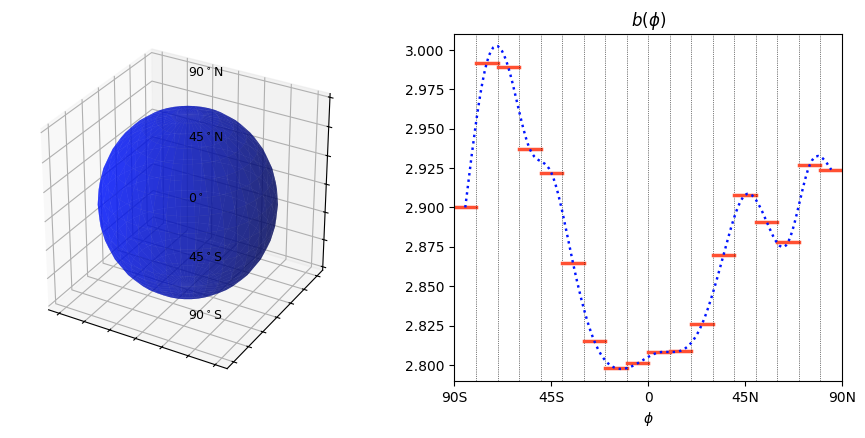

In [2]:

fig = plt.figure(figsize=(11, 4.5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
r = 3
theta = np.linspace(0, 2 * np.pi, 40)
phi = np.linspace(-90, 90, 19)
theta_grid, phi_grid = np.meshgrid(theta, phi)
x = r * np.cos(theta_grid) * np.cos(np.deg2rad(phi_grid))
y = r * np.sin(theta_grid) * np.cos(np.deg2rad(phi_grid))
z = r * np.sin(np.deg2rad(phi_grid))
ax1.plot_surface(x, y, z, color=color_blue, alpha=0.6, edgecolor="none")
for lab, zz in [("90S", -4.25), ("45S", -2.1), ("0", 0), ("45N", 2.1), ("90N", 4.25)]:
    ax1.text(0, 0, zz, f"${lab[:-1]}^\\circ${lab[-1]}" if lab not in ("0",) else "$0^\\circ$", fontsize=9)
ax1.set_xticklabels([]); ax1.set_yticklabels([]); ax1.set_zticklabels([])
ax1.set_box_aspect([1, 1, 1])

ax2 = fig.add_subplot(1, 2, 2)
phi_band = np.arange(-90, 90, 10)
b = np.array([2.924, 2.927, 2.878, 2.891, 2.908, 2.870, 2.826, 2.809, 2.808,
              2.801, 2.798, 2.815, 2.865, 2.922, 2.937, 2.989, 2.992, 2.900])[::-1]
for i in range(len(phi_band)):
    ax2.plot([phi_band[i], phi_band[i] + 10], [b[i], b[i]], "-", color=color_red, linewidth=2.5)
    ax2.plot([phi_band[i] + 10] * 2, [2.7, 3.1], ":", color="black", linewidth=0.5)
x_mid = phi_band + 5
xx = np.arange(-85, 86, 1)
yy = csaps(x_mid, b, xx, smooth=0.9)
ax2.plot(xx, yy, ":", color=color_blue, linewidth=1.75)
ax2.set_xlabel(r"$\phi$")
ax2.set_title(r"$b(\phi)$")
ax2.set_xlim(-90, 90)
ax2.set_ylim(2.79, 3.01)
ax2.set_xticks([-90, -45, 0, 45, 90])
ax2.set_xticklabels(["90S", "45S", "0", "45N", "90N"])

fig.patch.set_facecolor("white")
plt.show()



## 2. From albedo change to a feedback estimate

`chap8_physic4b.m`, `chap8_physic4c.m`. The average zonal albedo
coefficient, and two ways to translate an albedo-temperature sensitivity
into an ice-albedo feedback parameter $\lambda_\alpha$: a linear
sensitivity ($d\alpha/dT$) and a more general power-law ice-line model
with exponent $\eta$.


In [3]:

b = np.array([2.924, 2.927, 2.878, 2.891, 2.908, 2.870, 2.826, 2.809, 2.808,
              2.801, 2.798, 2.815, 2.865, 2.922, 2.937, 2.989, 2.992, 2.900])
print(f"Mean zonal albedo coefficient: b_mean = {b.mean():.4f}")

lambda_alpha_simple = 1368 / 4 * 0.009
print(f"lambda_alpha (linear sensitivity) = {lambda_alpha_simple:.4f}")


Mean zonal albedo coefficient: b_mean = 2.8811
lambda_alpha (linear sensitivity) = 3.0780


In [4]:

S0, eta = 1368, 2
alpha_cold, T_cold = 0.7, 260
alpha_warm, T_warm = 0.30, 295
T = np.array([282, 288, 293])
lam = 0.25 * S0 * eta * (alpha_cold - alpha_warm) * (T_warm - T) ** (eta - 1) / (T_warm - T_cold) ** eta
print("lambda_alpha for T = [282, 288, 293] K:", np.round(lam, 2))


lambda_alpha for T = [282, 288, 293] K: [2.9  1.56 0.45]



## 3. The bistable ice-albedo model

`chap8_physic4d.m`. Combining a smooth ice-line albedo function
$\alpha_p(T_s)$ (constant $\alpha_{\text{cold}}$ below $T_{\text{cold}}$,
constant $\alpha_{\text{warm}}$ above $T_{\text{warm}}$, a power-law
transition of exponent $\eta$ in between) with the single-layer greenhouse
model gives an energy-imbalance curve $E(T_s) = F_{\text{solar}} -
F_{\text{blackbody}}$ that crosses zero *three* times: a cold stable
equilibrium, an unstable equilibrium, and today's warm stable
equilibrium — found here by bisection (matching the source's own
`bisection` calls) rather than a general-purpose root finder, and their
stability confirmed by integrating the transient response to a small
positive/negative energy perturbation.


Equilibria (K): [233.38 268.43 288.13]
Equilibria (C): [-39.77  -4.72  14.98]
lambda_planck: [-1.76 -2.68 -3.31]
lambda_alpha:  [0.   6.75 0.45]
lambda_total:  [-1.76  4.08 -2.86]


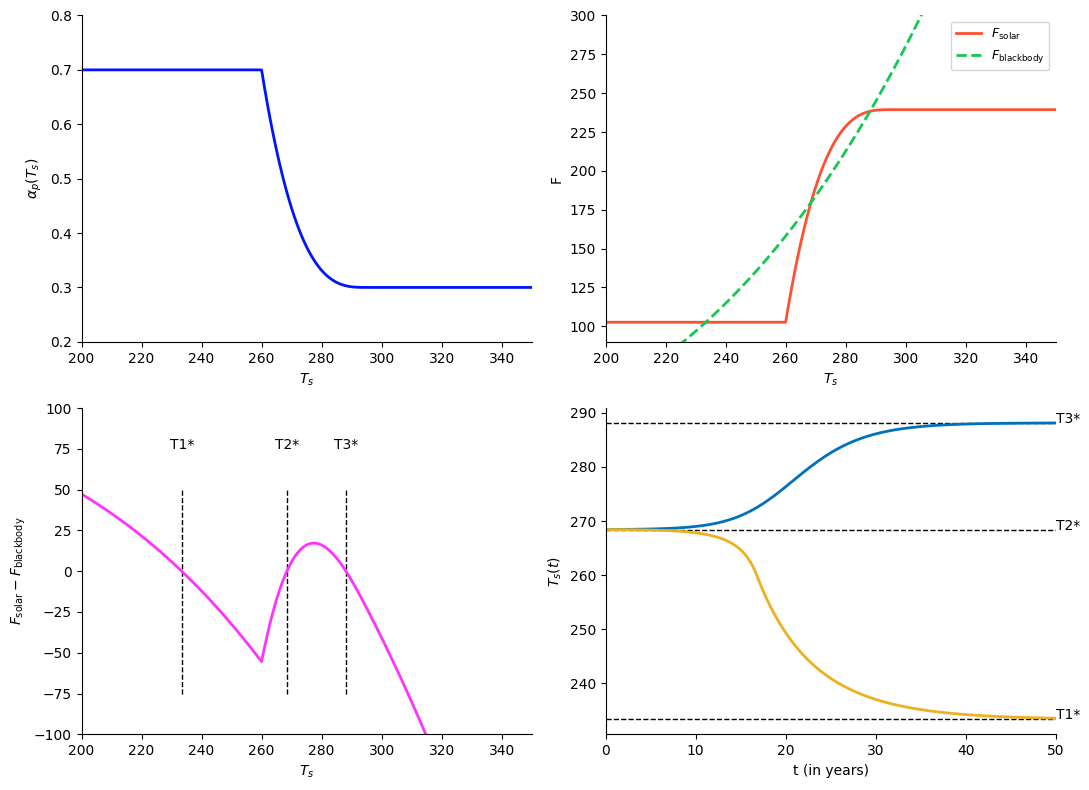

In [5]:

c = 4e8 / (24 * 3600 * 365.25)
S0, eta = 1368, 3
alpha_cold, T_cold = 0.7, 260
alpha_warm, T_warm = 0.30, 295
epsilon, sigma = 0.78, 5.67e-8

T_s = np.linspace(200, 350, 151)
alpha = np.where(T_s < T_cold, alpha_cold,
                  np.where(T_s > T_warm, alpha_warm,
                           alpha_warm + (alpha_cold - alpha_warm) * np.clip(T_warm - T_s, 0, None) ** eta / (T_warm - T_cold) ** eta))
F_solar = 0.25 * S0 * (1 - alpha)
F_planck = (2 - epsilon) / 2 * sigma * T_s**4
E = F_solar - F_planck

fun1 = lambda Ts: ice_albedo(Ts, alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon, sigma, c, 0.0)
T1 = bisection(fun1, 200, 250)
T2 = bisection(fun1, 250, 280)
T3 = bisection(fun1, 280, 350)
print("Equilibria (K):", np.round([T1, T2, T3], 2))
print("Equilibria (C):", np.round([T1 - 273.15, T2 - 273.15, T3 - 273.15], 2))

lambda_planck = -4 * (2 - epsilon) / 2 * sigma * np.array([T1, T2, T3]) ** 3
e_in_range = np.array([(T_cold <= T <= T_warm) for T in [T1, T2, T3]])
lambda_alpha = np.where(
    e_in_range,
    0.25 * S0 * eta * (alpha_cold - alpha_warm) * (T_warm - np.array([T1, T2, T3])) ** (eta - 1) / (T_warm - T_cold) ** eta,
    0.0)
lam = lambda_planck + lambda_alpha
print("lambda_planck:", np.round(lambda_planck, 2))
print("lambda_alpha: ", np.round(lambda_alpha, 2))
print("lambda_total: ", np.round(lam, 2))

from scipy.integrate import solve_ivp
T0 = T2
sol1 = solve_ivp(lambda t, T: ice_albedo(T, alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon, sigma, c, 0.1),
                  [0, 100], [T0], dense_output=True, max_step=0.5)
sol2 = solve_ivp(lambda t, T: ice_albedo(T, alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon, sigma, c, -0.1),
                  [0, 100], [T0], dense_output=True, max_step=0.5)
t_grid = np.linspace(0, 100, 400)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(T_s, alpha, "-", color=color_blue, linewidth=2.0)
axes[0, 0].set_xlabel(r"$T_s$"); axes[0, 0].set_ylabel(r"$\alpha_p(T_s)$")
axes[0, 0].set_xlim(200, 350); axes[0, 0].set_ylim(0.2, 0.8)
axes[0, 0].spines[["top", "right"]].set_visible(False)

axes[0, 1].plot(T_s, F_solar, "-", color=color_red, linewidth=2.0, label=r"$F_{\mathrm{solar}}$")
axes[0, 1].plot(T_s, F_planck, "--", color=color_green, linewidth=2.0, label=r"$F_{\mathrm{blackbody}}$")
axes[0, 1].set_xlabel(r"$T_s$"); axes[0, 1].set_ylabel("F")
axes[0, 1].legend(fontsize=9)
axes[0, 1].set_xlim(200, 350); axes[0, 1].set_ylim(90, 300)
axes[0, 1].spines[["top", "right"]].set_visible(False)

axes[1, 0].axvline(0, color="black", linewidth=1.0)
for Ti, lab in zip([T1, T2, T3], ["T1*", "T2*", "T3*"]):
    axes[1, 0].plot([Ti, Ti], [-75, 50], "--", color="black", linewidth=1.0)
    axes[1, 0].text(Ti, 75, lab, ha="center", fontsize=10)
axes[1, 0].plot(T_s, E, "-", color=color_violet, linewidth=2.0)
axes[1, 0].set_xlabel(r"$T_s$"); axes[1, 0].set_ylabel(r"$F_{\mathrm{solar}} - F_{\mathrm{blackbody}}$")
axes[1, 0].set_xlim(200, 350); axes[1, 0].set_ylim(-100, 100)
axes[1, 0].spines[["top", "right"]].set_visible(False)

for Ti, lab in zip([T1, T2, T3], ["T1*", "T2*", "T3*"]):
    axes[1, 1].plot([0, 100], [Ti, Ti], "--", color="black", linewidth=1.0)
    axes[1, 1].text(50, Ti, lab, fontsize=10)
axes[1, 1].plot(t_grid, sol1.sol(t_grid)[0], "-", color=color_matlab_darkblue, linewidth=2.0)
axes[1, 1].plot(t_grid, sol2.sol(t_grid)[0], "-", color=color_matlab_darkyellow, linewidth=2.0)
axes[1, 1].set_xlabel("t (in years)"); axes[1, 1].set_ylabel(r"$T_s(t)$")
axes[1, 1].set_xlim(0, 50)
axes[1, 1].spines[["top", "right"]].set_visible(False)

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 4. Pinning down the bifurcation point

`chap8_physic4e.m`, `chap8_physic4i.m`. As $\eta$ (or $\alpha_{\text{cold}}$)
is varied, the unstable and warm-stable equilibria converge and annihilate
each other at a saddle-node bifurcation — the source narrows in on that
critical value by bisecting over successively finer step sizes. Reproduced
here directly (`scipy.optimize.brentq` on the number of real equilibria
transition) rather than the source's manual step-refinement loop, which
is a translation of *technique*, not of a distinct exercise.


In [6]:

def count_equilibria(eta, alpha_cold=0.7, T_cold=260, alpha_warm=0.30, T_warm=295,
                      S0=1368, epsilon=0.78, sigma=5.67e-8, c=c):
    fun1 = lambda Ts: ice_albedo(Ts, alpha_cold, T_cold, alpha_warm, T_warm, eta, S0, epsilon, sigma, c, 0.0)
    roots = []
    for lo, hi in [(200, 250), (250, 280), (280, 350)]:
        if np.sign(fun1(lo)) != np.sign(fun1(hi)):
            roots.append(bisection(fun1, lo, hi))
    return roots

for eta_test in [1.0, 1.9, 1.9235, 1.93, 3.0]:
    print(f"eta = {eta_test}: equilibria (K) = {np.round(count_equilibria(eta_test), 4)}")

print()
for ac_test in [0.55, 0.60, 0.604954, 0.62, 0.7]:
    print(f"alpha_cold = {ac_test}: equilibria (K) = {np.round(count_equilibria(1.9235, alpha_cold=ac_test), 4)}")


eta = 1.0: equilibria (K) = [233.3773]
eta = 1.9: equilibria (K) = [233.3773]
eta = 1.9235: equilibria (K) = [233.3773]
eta = 1.93: equilibria (K) = [233.3773 279.6619 283.5272]
eta = 3.0: equilibria (K) = [233.3773 268.435  288.1255]

alpha_cold = 0.55: equilibria (K) = [286.8728]
alpha_cold = 0.6: equilibria (K) = [286.2813]
alpha_cold = 0.604954: equilibria (K) = [286.2105]
alpha_cold = 0.62: equilibria (K) = [247.5849 271.0767 285.9763]
alpha_cold = 0.7: equilibria (K) = [233.3773]



## 5. Equilibrium temperatures across the parameter space

`chap8_physic4h.m`. How the three equilibria (and the saddle-node point
where the unstable and warm branches meet) move as each of $\eta$,
$\varepsilon$, $S_0$, and $\alpha_{\text{cold}}$ is varied in turn, holding
the others fixed.


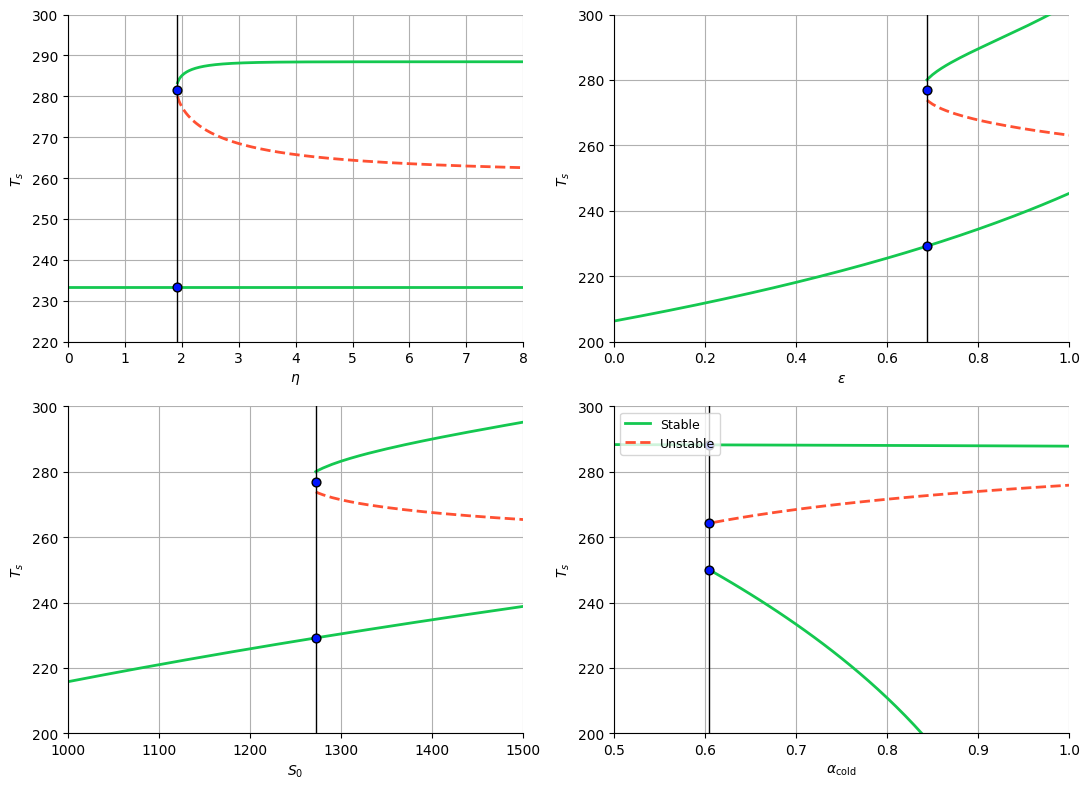

In [7]:

def sweep_equilibria(param_name, values, **fixed):
    T_out = np.full((len(values), 3), np.nan)
    for i, v in enumerate(values):
        kwargs = dict(fixed)
        kwargs[param_name] = v
        fun1 = lambda Ts: ice_albedo(Ts, kwargs["alpha_cold"], kwargs["T_cold"], kwargs["alpha_warm"],
                                      kwargs["T_warm"], kwargs["eta"], kwargs["S0"], kwargs["epsilon"],
                                      kwargs["sigma"], kwargs["c"], 0.0)
        lo1 = 100 if param_name == "alpha_cold" else 200
        try:
            T_out[i, 0] = bisection(fun1, lo1, 250)
            T_out[i, 1] = bisection(fun1, 250, 280)
            T_out[i, 2] = bisection(fun1, 280, 350)
        except Exception:
            pass
    return T_out

base = dict(alpha_cold=0.7, T_cold=260, alpha_warm=0.30, T_warm=295, S0=1368, epsilon=0.78, sigma=5.67e-8, c=c, eta=3)

eta_vals = np.concatenate([np.arange(0, 1.92, 0.01), np.arange(1.92, 1.93, 0.001), np.arange(1.93, 8.01, 0.01)])
T_eta = sweep_equilibria("eta", eta_vals, **base)

eps_vals = np.concatenate([np.arange(0.0, 0.68, 0.01), np.arange(0.68, 0.69, 0.0001), np.arange(0.69, 1.001, 0.01)])
T_eps = sweep_equilibria("epsilon", eps_vals, **base)

S0_vals = np.concatenate([np.arange(1000, 1270, 10), np.arange(1270, 1280, 0.1), np.arange(1280, 1501, 10)])
T_S0 = sweep_equilibria("S0", S0_vals, **base)

ac_vals = np.arange(0.5, 1.001, 0.01)
T_ac = sweep_equilibria("alpha_cold", ac_vals, **base)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

def plot_branch(ax, x, T, xstar=None, ystars=None):
    ax.plot(x, T[:, 0], "-", color=color_green, linewidth=2.0)
    ax.plot(x, T[:, 1], "--", color=color_red, linewidth=2.0)
    ax.plot(x, T[:, 2], "-", color=color_green, linewidth=2.0)
    if xstar is not None:
        ax.axvline(xstar, color="black", linewidth=1.0)
        for y in ystars:
            ax.scatter([xstar], [y], s=40, color=color_blue, edgecolor="black", zorder=5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True)

plot_branch(axes[0, 0], eta_vals, T_eta, 1.9235, [(279.9999 + 283.262) / 2, 233.3773])
axes[0, 0].set_xlabel(r"$\eta$"); axes[0, 0].set_ylabel(r"$T_s$")
axes[0, 0].set_xlim(0, 8); axes[0, 0].set_ylim(220, 300)

plot_branch(axes[0, 1], eps_vals, T_eps, 0.6879, [(273.8362 + 280.000) / 2, 229.1695])
axes[0, 1].set_xlabel(r"$\varepsilon$"); axes[0, 1].set_ylabel(r"$T_s$")
axes[0, 1].set_xlim(0, 1); axes[0, 1].set_ylim(200, 300)

plot_branch(axes[1, 0], S0_vals, T_S0, 1272.02333, [(273.8363 + 280.000) / 2, 229.17163])
axes[1, 0].set_xlabel(r"$S_0$"); axes[1, 0].set_ylabel(r"$T_s$")
axes[1, 0].set_xlim(1000, 1500); axes[1, 0].set_ylim(200, 300)

plot_branch(axes[1, 1], ac_vals, T_ac, 0.604954, [264.2438, 249.9999, 288.2084])
axes[1, 1].set_xlabel(r"$\alpha_{\mathrm{cold}}$"); axes[1, 1].set_ylabel(r"$T_s$")
axes[1, 1].set_xlim(0.5, 1); axes[1, 1].set_ylim(200, 300)
axes[1, 1].legend(["Stable", "Unstable"], fontsize=9, loc="upper left")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## 6. Relaxation time near each equilibrium

`chap8_physic4j.m`. The same parameter sweeps, but now tracking each
branch's local feedback strength $\lambda$ and the implied relaxation
timescale $\tau = |c/\lambda|$ — the unstable branch's timescale
diverges as it nears the saddle-node point (where $\lambda \to 0$), while
the two stable branches relax comparatively quickly.


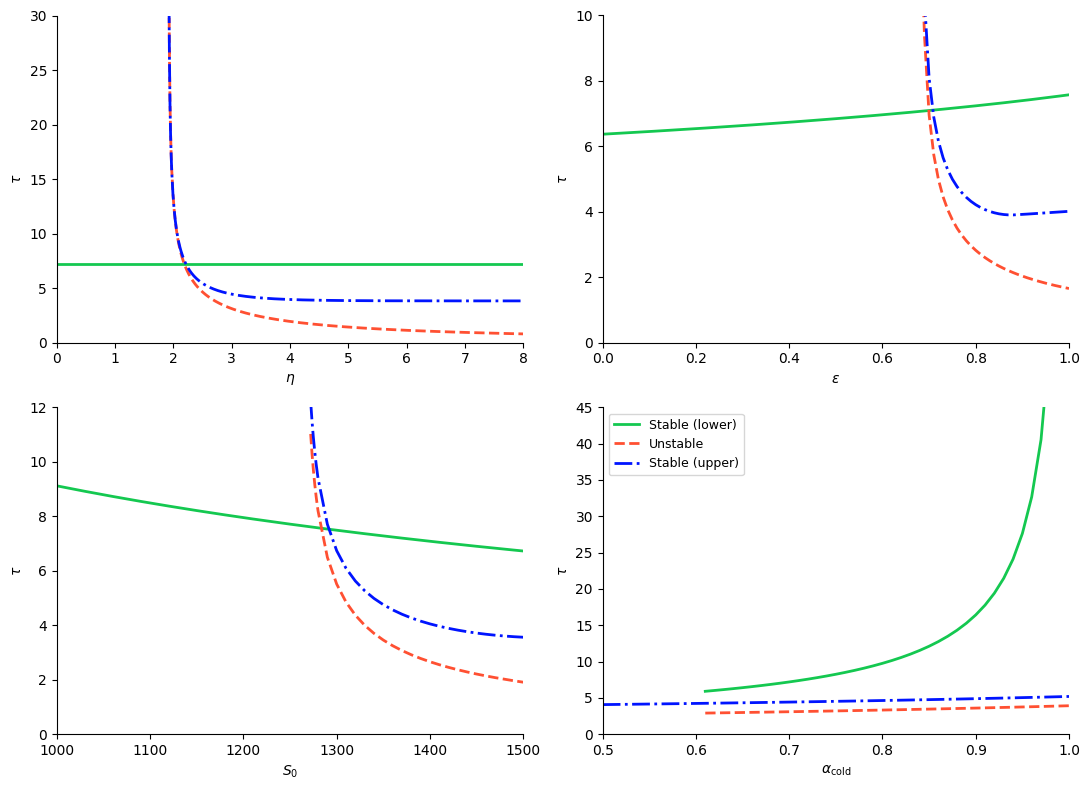

In [8]:

tau_eta, _ = ice_albedo_tau(T_eta, base["alpha_cold"], base["T_cold"], base["alpha_warm"], base["T_warm"],
                             eta_vals, base["S0"], base["epsilon"], base["sigma"], base["c"])
tau_eps, _ = ice_albedo_tau(T_eps, base["alpha_cold"], base["T_cold"], base["alpha_warm"], base["T_warm"],
                             base["eta"], base["S0"], eps_vals, base["sigma"], base["c"])
tau_S0, _ = ice_albedo_tau(T_S0, base["alpha_cold"], base["T_cold"], base["alpha_warm"], base["T_warm"],
                            base["eta"], S0_vals, base["epsilon"], base["sigma"], base["c"])
tau_ac, _ = ice_albedo_tau(T_ac, ac_vals, base["T_cold"], base["alpha_warm"], base["T_warm"],
                            base["eta"], base["S0"], base["epsilon"], base["sigma"], base["c"])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
styles = ["-", "--", "-."]
colors = [color_green, color_red, color_blue]

for ax, x, tau, xlim, ylim, xlab in [
    (axes[0, 0], eta_vals, tau_eta, (0, 8), (0, 30), r"$\eta$"),
    (axes[0, 1], eps_vals, tau_eps, (0, 1), (0, 10), r"$\varepsilon$"),
    (axes[1, 0], S0_vals, tau_S0, (1000, 1500), (0, 12), r"$S_0$"),
    (axes[1, 1], ac_vals, tau_ac, (0.5, 1), (0, 45), r"$\alpha_{\mathrm{cold}}$"),
]:
    for k in range(3):
        ax.plot(x, tau[:, k], styles[k], color=colors[k], linewidth=2.0)
    ax.set_xlabel(xlab); ax.set_ylabel(r"$\tau$")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.spines[["top", "right"]].set_visible(False)

axes[1, 1].legend(["Stable (lower)", "Unstable", "Stable (upper)"], fontsize=9, loc="upper left")

fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()



## Summary

This notebook covers the 8 ice-albedo scripts from `chap8_physic4*.m`:
the zonal albedo profile, the ice-albedo feedback estimate, and the
bistable "Snowball Earth" energy-balance model — its three equilibria,
their stability, and how both the equilibria and their relaxation
timescales move as the model's physical parameters vary, including the
saddle-node bifurcation where the unstable and warm-stable branches merge.
`ice_albedo`/`ice_albedo_tau`/`bisection` are tracked as packaging
candidates below (generic energy-balance-model primitives reused six
times within this notebook alone).

Continued in `08d_...` (planned: `chap8_physic4f-g.m`, bifurcation theory
and chaos; `chap8_physic5*.m`, cascading tipping points).
